In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from MDP.IRSwaps.IRSwapMDP import IRSwapMDP

In [87]:
curve_mdp = IRSwapMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x8")

In [91]:
# timestamp = NY_tz.localize(datetime.datetime(2025, 9, 19, 15, 00))
timestamp = NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00)) 
# timestamp = "live" 

In [93]:
rlcurve = curve_mdp._get_curve(curve_name="USD-FEDFUNDS", timestamp=timestamp)
# rlcurve = rl_usd_sofr_mt_curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp="live")

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 30/30 [00:01<00:00, 15.87it/s]


SUCCESS: `conv_tol` reached after 14 iterations (levenberg_marquardt), `f_val`: 0.0003744663251090161, `time`: 0.2841s
SUCCESS: `conv_tol` reached after 70 iterations (levenberg_marquardt), `f_val`: 22735.64771089749, `time`: 1.3467s


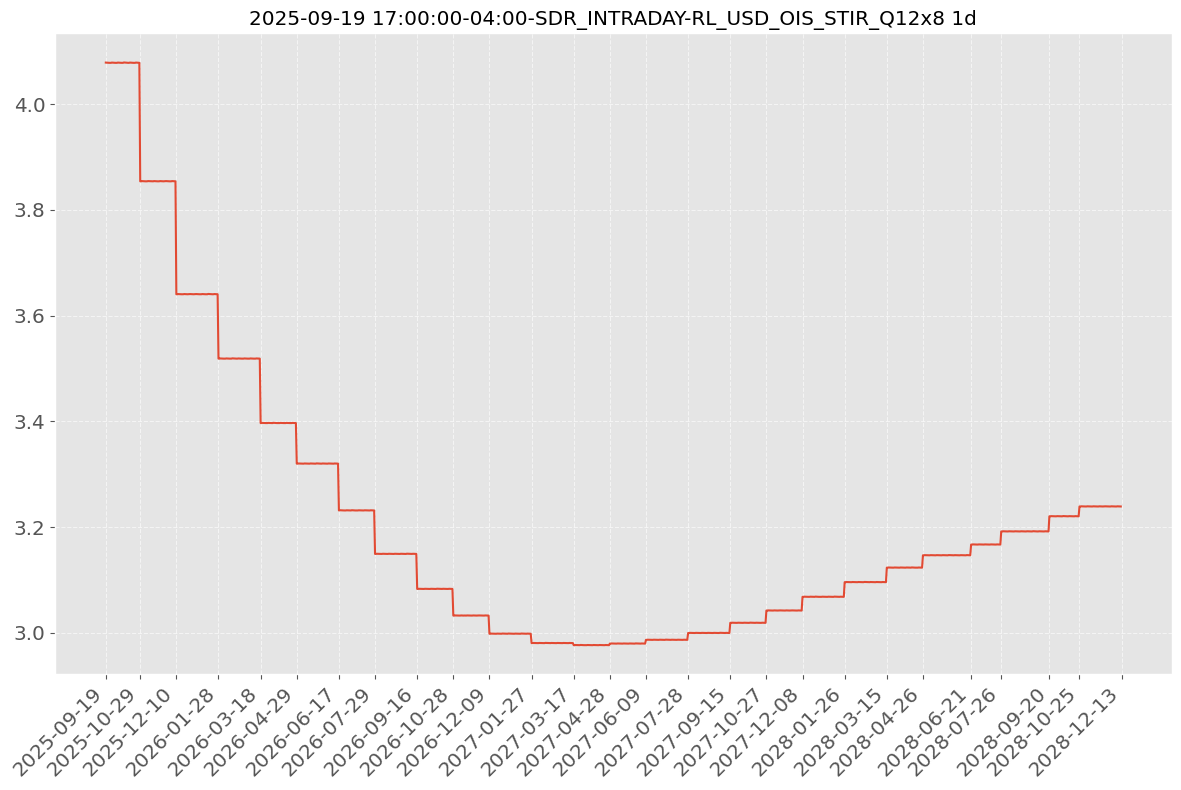

In [99]:
# x_data_num, y_data_rate = rl_sofr_curve._plot_rates("1D", left=rl.NoInput(0), right=rl.NoInput(0))
x_data_num, y_data_rate = rlcurve.handle()._plot_rates("1D", left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())


fig, ax = plt.subplots()
ax.plot(x_business_days, y_business_rates)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45, ha="right")  # Rotate ticks for better readability
ax.grid(True, linestyle="--", alpha=0.6)

curve_nodes = rlcurve.handle().nodes._nodes.keys()
ticks = [t.tz_localize(None) if getattr(t, "tzinfo", None) else t for t in curve_nodes]
ax.set_xticks(mdates.date2num(ticks))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.title(f"{rlcurve.meta()["id"]} 1d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
fomc_dated_ois = {
    "sep25": (rl.dt(2025, 9, 17), rl.dt(2025, 10, 29)),
    "oct25": (rl.dt(2025, 10, 29), rl.dt(2025, 12, 10)),
    "dec25": (rl.dt(2025, 12, 10), rl.dt(2026, 1, 28)),
    "jan26": (rl.dt(2026, 1, 28), rl.dt(2026, 3, 18)),
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

In [98]:
build_fomc_ois(meeting="jun26", rl_curve=rlcurve.handle(), risk=50_000).rate()

<Dual: 3.237492, (2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x86, 2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x85, 2025-09-19 17:00:00-04:00-SDR_INTRADAY-RL_USD_OIS_STIR_Q12x87, ...), [884.2, 0.0, -887.5, ...]>

In [7]:
from MDP.IRSwaps.GSQUANT.rl_basic.build import build_rl_basic_gsquant_curve

In [8]:
gsq_curve = build_rl_basic_gsquant_curve(curve="JPY-TONAR", as_of=datetime.date(2025, 9, 19))

SUCCESS: `func_tol` reached after 6 iterations (levenberg_marquardt), `f_val`: 2.9819184323273765e-10, `time`: 0.0188s


In [9]:
x_data_num, y_data_rate = gsq_curve._plot_rates("1D", left=rl.NoInput(0), right=rl.NoInput(0))
plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

x_business_days = list(filtered_plot_data.keys())
y_business_rates = list(filtered_plot_data.values())

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_business_days, y=y_business_rates, mode="lines", name="1D"))


def _to_naive_dt(t):
    t = pd.Timestamp(t)
    return t.tz_localize(None) if t.tzinfo is not None else t

curve_nodes = gsq_curve.nodes._nodes.keys()
tick_vals = [_to_naive_dt(t) for t in curve_nodes]
tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]

fig.update_layout(
    # title=f"{curve_id} 1d | {snap.strftime('%Y-%m-%dT%H:%M:%S %Z') if type(datetime.datetime) == type(snap) else snap}",
    template="plotly_dark",
    margin=dict(l=40, r=20, t=60, b=80),
    xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
    height=550,
    yaxis=dict(showgrid=True),
)
fig.update_xaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikemode="across",
    showgrid=True,
)
fig.update_yaxes(
    showspikes=True,
    spikecolor="white",
    spikesnap="cursor",
    spikethickness=0.5,
    showgrid=True,
)

fig.show()

In [103]:
bonds = rl.IRS(
    effective=rl.dt(2025, 9, 23), termination=rl.dt(2027, 9, 23), spec="usd_irs", curves=gsq_curve, notional=100_000_000 
)

In [100]:
bonds.rate()

<Dual: 3.337241, (2025-09-19-GSQUANT-rl_basic_USD-SOFR-1D0, 2025-09-19-GSQUANT-rl_basic_USD-SOFR-1D1, 2025-09-19-GSQUANT-rl_basic_USD-SOFR-1D2, ...), [49.4, 2.6, 0.0, ...]>